In [1]:
#1
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [2]:
#2
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

print("Machine Learning Libraries Imported!")

Machine Learning Libraries Imported!


In [3]:
#3
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

print("Classification Models Imported!")

Classification Models Imported!


In [4]:
#4
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Evaluation Libraries Imported!")

Evaluation Libraries Imported!


In [5]:
#5
import tensorflow as tf

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Embedding,
    LSTM,
    Dense,
    Dropout
)

from tensorflow.keras.preprocessing.text import Tokenizer

from tensorflow.keras.preprocessing.sequence import pad_sequences

print("TensorFlow Version :", tf.__version__)

TensorFlow Version : 2.20.0


In [6]:
#6
from tensorflow.keras.datasets import imdb

# Load IMDb dataset
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=10000)

print("Dataset Loaded Successfully!")

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Dataset Loaded Successfully!


In [7]:
#7
print("Training Samples :", len(x_train))
print("Testing Samples  :", len(x_test))

print("\nTraining Labels :", len(y_train))
print("Testing Labels  :", len(y_test))

Training Samples : 25000
Testing Samples  : 25000

Training Labels : 25000
Testing Labels  : 25000


In [8]:
#8
print("First Review (Encoded):")
print(x_train[0])

print("\nSentiment Label:")
print(y_train[0])

First Review (Encoded):
[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 19, 178, 32]

Sentiment Label:
1


In [9]:
#9
word_index = imdb.get_word_index()

reverse_word_index = {
    value: key
    for key, value in word_index.items()
}

decoded_review = " ".join(
    reverse_word_index.get(i - 3, "?")
    for i in x_train[0]
)

print(decoded_review)

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
? this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert ? is an amazing actor and now the same being director ? father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for ? and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also ? to the two little boy's that played the ? of norman and paul they were just brilliant children are often left out of the ? list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and should

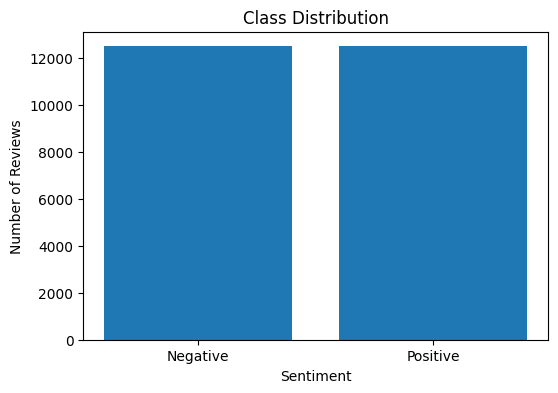

In [10]:
#10
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.bar(
    ["Negative", "Positive"],
    [sum(y_train == 0), sum(y_train == 1)]
)

plt.title("Class Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.show()

In [11]:
max_length = 200

x_train = pad_sequences(
    x_train,
    maxlen=max_length,
    padding='post'
)

x_test = pad_sequences(
    x_test,
    maxlen=max_length,
    padding='post'
)

print("Sequences Padded Successfully!")

Sequences Padded Successfully!


In [12]:
print("Training Data Shape :", x_train.shape)
print("Testing Data Shape :", x_test.shape)

Training Data Shape : (25000, 200)
Testing Data Shape : (25000, 200)


In [13]:
from sklearn.model_selection import train_test_split

x_train, x_val, y_train, y_val = train_test_split(
    x_train,
    y_train,
    test_size=0.2,
    random_state=42
)

print("Training Shape :", x_train.shape)
print("Validation Shape :", x_val.shape)

Training Shape : (20000, 200)
Validation Shape : (5000, 200)


In [14]:
print("First Review After Padding:\n")

print(x_train[0])

print("\nLength :", len(x_train[0]))

First Review After Padding:

[  24   15  821   66   10   10   45  578   15    4   20  805    8   30
   17  821    5 1621   17  614  190    4   20    9   43   32   99 1214
   18   15    8  157   46   17 1436    4    2    5    2    9   32 1796
    5 1214  267   17   73   17 4413   36   26  400   43 4562   83    4
 1873  247   74   83    4  250  540   82    4   96    4  250 8306    8
   32    4    2    9  184 3966   13  384   48   14   16  147 1348   59
   62   69 9420   12   46   50    9   53    2   74 1930   11   14   31
  151   10   10    4   20    9  540  364  352    5   45    6    2  589
   33  269    8 2715  142 1621    5  821   17   73   17  204    5 2908
   19   55 1763 4697   92   66  104   14   20   93   76 1488  151   33
    4   58   12  188  626  151   12  215   69  224  142   73  237    6
  964    7 1446 2289  188  626  103   14   31   10   10  451    7 1465
    5  599   80   91 1329   30  685   34   14   20  151   50   26  131
   49 7717   84   46   50   37   80   79    6 19

In [15]:
vocab_size = 10000

print("Vocabulary Size :", vocab_size)

Vocabulary Size : 10000


In [16]:
print("Positive Reviews :", sum(y_train == 1))
print("Negative Reviews :", sum(y_train == 0))

Positive Reviews : 9937
Negative Reviews : 10063


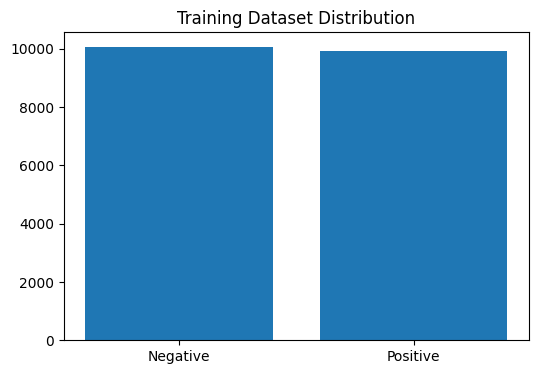

In [17]:
plt.figure(figsize=(6,4))

plt.bar(
    ["Negative", "Positive"],
    [sum(y_train == 0), sum(y_train == 1)]
)

plt.title("Training Dataset Distribution")

plt.show()

In [18]:
print("="*50)
print("DATA PREPROCESSING COMPLETED")
print("="*50)

print("Training Samples :", len(x_train))
print("Validation Samples :", len(x_val))
print("Testing Samples :", len(x_test))

DATA PREPROCESSING COMPLETED
Training Samples : 20000
Validation Samples : 5000
Testing Samples : 25000


In [19]:
# Cell 19

x_train_text = [" ".join(map(str, review)) for review in x_train]
x_test_text = [" ".join(map(str, review)) for review in x_test]

print("Text Conversion Completed!")

Text Conversion Completed!


In [20]:
# Cell 20

tfidf = TfidfVectorizer(max_features=5000)

x_train_tfidf = tfidf.fit_transform(x_train_text)

x_test_tfidf = tfidf.transform(x_test_text)

print("TF-IDF Vectorization Completed!")

TF-IDF Vectorization Completed!


In [21]:
# Cell 21

print("Training TF-IDF Shape :", x_train_tfidf.shape)
print("Testing TF-IDF Shape :", x_test_tfidf.shape)

Training TF-IDF Shape : (20000, 5000)
Testing TF-IDF Shape : (25000, 5000)


In [22]:
# Cell 22

logistic_model = LogisticRegression(max_iter=1000)

logistic_model.fit(x_train_tfidf, y_train)

print("Logistic Regression Model Trained Successfully!")

Logistic Regression Model Trained Successfully!


In [23]:
# Cell 23

lr_predictions = logistic_model.predict(x_test_tfidf)

print("Predictions Generated Successfully!")

Predictions Generated Successfully!


In [24]:
# Cell 24

lr_accuracy = accuracy_score(y_test, lr_predictions)

print("Accuracy :", round(lr_accuracy,4))

Accuracy : 0.8729


In [25]:
# Cell 25

lr_precision = precision_score(y_test, lr_predictions)

lr_recall = recall_score(y_test, lr_predictions)

lr_f1 = f1_score(y_test, lr_predictions)

print("Precision :", round(lr_precision,4))
print("Recall :", round(lr_recall,4))
print("F1 Score :", round(lr_f1,4))

Precision : 0.8696
Recall : 0.8773
F1 Score : 0.8734


In [26]:
# Cell 26

print(classification_report(
    y_test,
    lr_predictions
))

              precision    recall  f1-score   support

           0       0.88      0.87      0.87     12500
           1       0.87      0.88      0.87     12500

    accuracy                           0.87     25000
   macro avg       0.87      0.87      0.87     25000
weighted avg       0.87      0.87      0.87     25000



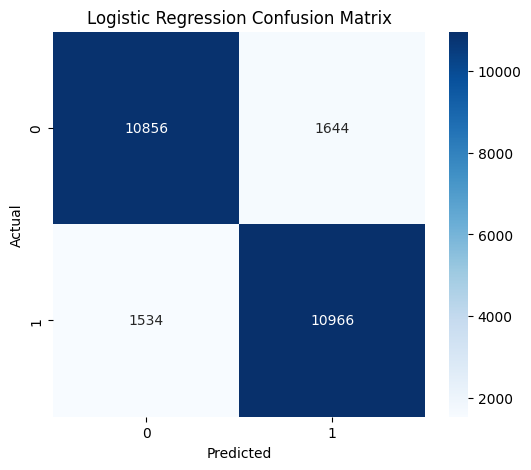

In [27]:
# Cell 27

cm = confusion_matrix(y_test, lr_predictions)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")

plt.show()

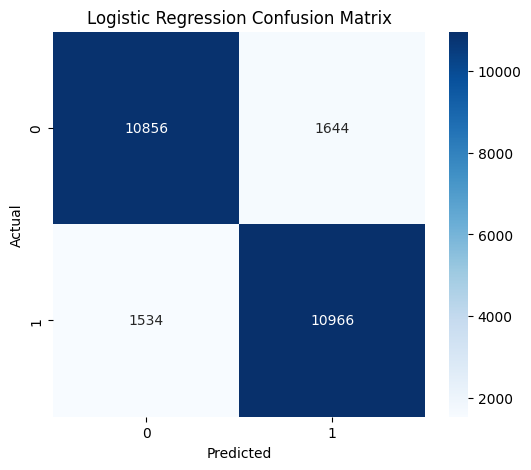

In [28]:
# Cell 28

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")

plt.savefig("confusion_matrix_lr.png")

plt.show()

In [29]:
# Cell 29

svm_model = LinearSVC()

svm_model.fit(x_train_tfidf, y_train)

print("SVM Model Trained Successfully!")

SVM Model Trained Successfully!


In [30]:
# Cell 30

svm_predictions = svm_model.predict(x_test_tfidf)

print("Predictions Generated Successfully!")

Predictions Generated Successfully!


In [31]:
# Cell 31

svm_accuracy = accuracy_score(y_test, svm_predictions)

print("SVM Accuracy :", round(svm_accuracy, 4))

SVM Accuracy : 0.8568


In [32]:
# Cell 32

svm_precision = precision_score(y_test, svm_predictions)

svm_recall = recall_score(y_test, svm_predictions)

svm_f1 = f1_score(y_test, svm_predictions)

print("Precision :", round(svm_precision,4))
print("Recall :", round(svm_recall,4))
print("F1 Score :", round(svm_f1,4))

Precision : 0.8588
Recall : 0.8541
F1 Score : 0.8564


In [33]:
# Cell 33

print(classification_report(
    y_test,
    svm_predictions
))

              precision    recall  f1-score   support

           0       0.85      0.86      0.86     12500
           1       0.86      0.85      0.86     12500

    accuracy                           0.86     25000
   macro avg       0.86      0.86      0.86     25000
weighted avg       0.86      0.86      0.86     25000



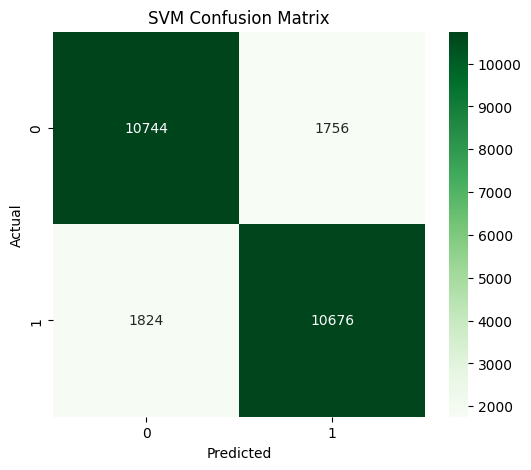

In [34]:
# Cell 34

svm_cm = confusion_matrix(y_test, svm_predictions)

plt.figure(figsize=(6,5))

sns.heatmap(
    svm_cm,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SVM Confusion Matrix")

plt.show()

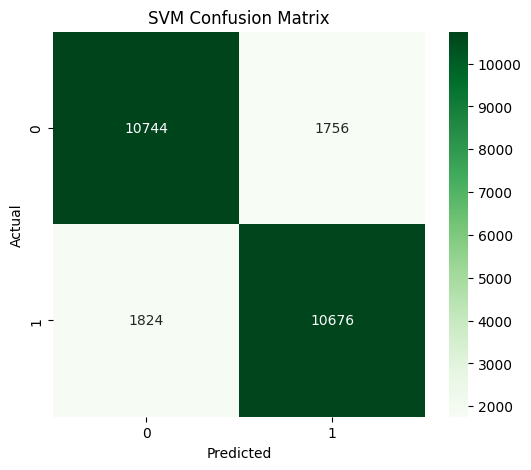

In [35]:
# Cell 35

plt.figure(figsize=(6,5))

sns.heatmap(
    svm_cm,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SVM Confusion Matrix")

plt.savefig("confusion_matrix_svm.png")

plt.show()

In [36]:
# Cell 36

comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "SVM"],
    "Accuracy": [lr_accuracy, svm_accuracy],
    "Precision": [lr_precision, svm_precision],
    "Recall": [lr_recall, svm_recall],
    "F1 Score": [lr_f1, svm_f1]
})

print(comparison)

                 Model  Accuracy  Precision   Recall  F1 Score
0  Logistic Regression   0.87288   0.869627  0.87728  0.873437
1                  SVM   0.85680   0.858752  0.85408  0.856409


In [37]:
# Cell 37

vocab_size = 10000

embedding_dim = 64

model = Sequential()

model.add(Embedding(vocab_size, embedding_dim, input_length=max_length))

model.add(LSTM(64))

model.add(Dropout(0.5))

model.add(Dense(1, activation='sigmoid'))

print("LSTM Model Created Successfully!")

LSTM Model Created Successfully!


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [38]:
# Cell 38

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [39]:
# Cell 39

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Model Compiled Successfully!")

Model Compiled Successfully!


In [56]:
# Cell 40

import time

start_time = time.time()

history = model.fit(

    x_train,

    y_train,

    epochs=10,

    batch_size=64,

    validation_data=(x_val, y_val),

    verbose=1

)

end_time = time.time()

print("Training Time :", round(end_time-start_time,2), "seconds")

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 50s 158ms/step - accuracy: 0.9909 - loss: 0.0441 - val_accuracy: 0.8324 - val_loss: 0.7612
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 80s 152ms/step - accuracy: 0.9910 - loss: 0.0412 - val_accuracy: 0.8320 - val_loss: 0.7783
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 83s 156ms/step - accuracy: 0.9927 - loss: 0.0359 - val_accuracy: 0.8256 - val_loss: 0.8891
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 81s 152ms/step - accuracy: 0.9901 - loss: 0.0430 - val_accuracy: 0.8298 - val_loss: 0.8290
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 49s 156ms/step - accuracy: 0.9918 - loss: 0.0371 - val_accuracy: 0.8330 - val_loss: 0.8130
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 80s 149ms/step - accuracy: 0.9903 - loss: 0.0411 - val_accuracy: 0.8288 - val_loss: 0.9030
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 84s 155ms/step - accuracy: 0.9955 - loss: 0.0238 - val_accuracy: 0.8332 - val_loss: 0.8946
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 80s 149ms/step - accuracy: 0.9965 - loss: 0

In [57]:
# Cell 41

loss, accuracy = model.evaluate(x_test, y_test)

print("Test Loss :", round(loss,4))

print("Test Accuracy :", round(accuracy,4))

782/782 ━━━━━━━━━━━━━━━━━━━━ 22s 28ms/step - accuracy: 0.8293 - loss: 0.9512
Test Loss : 0.9512
Test Accuracy : 0.8293


In [44]:
# Cell 42

prediction_prob = model.predict(x_test)

prediction = (prediction_prob > 0.5).astype(int)

print("Predictions Generated Successfully!")

782/782 ━━━━━━━━━━━━━━━━━━━━ 22s 28ms/step
Predictions Generated Successfully!


In [45]:
# Cell 43

precision = precision_score(y_test, prediction)

recall = recall_score(y_test, prediction)

f1 = f1_score(y_test, prediction)

print("Precision :", round(precision,4))

print("Recall :", round(recall,4))

print("F1 Score :", round(f1,4))

Precision : 0.8423
Recall : 0.8223
F1 Score : 0.8322


In [46]:
# Cell 44

print(classification_report(y_test, prediction))

              precision    recall  f1-score   support

           0       0.83      0.85      0.84     12500
           1       0.84      0.82      0.83     12500

    accuracy                           0.83     25000
   macro avg       0.83      0.83      0.83     25000
weighted avg       0.83      0.83      0.83     25000



In [47]:
# Cell 45

model.save("lstm_sentiment_model.keras")

print("Model Saved Successfully!")

Model Saved Successfully!


In [58]:
# Cell 46

import pickle

with open("history.pkl", "wb") as file:
    pickle.dump(history.history, file)

print("Training History Saved Successfully!")

Training History Saved Successfully!


In [59]:
print("history" in globals())

True


In [60]:
from tensorflow.keras.models import load_model
import pickle

model = load_model("lstm_sentiment_model.keras")

with open("history.pkl", "rb") as file:
    history_data = pickle.load(file)

print("Model Loaded Successfully!")

Model Loaded Successfully!


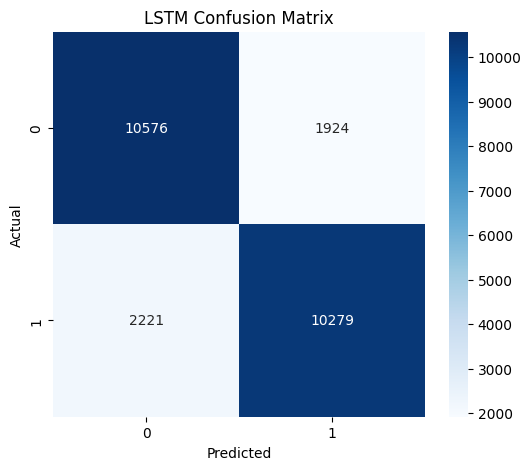

In [61]:
# Cell 45

cm = confusion_matrix(y_test, prediction)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("LSTM Confusion Matrix")

plt.show()

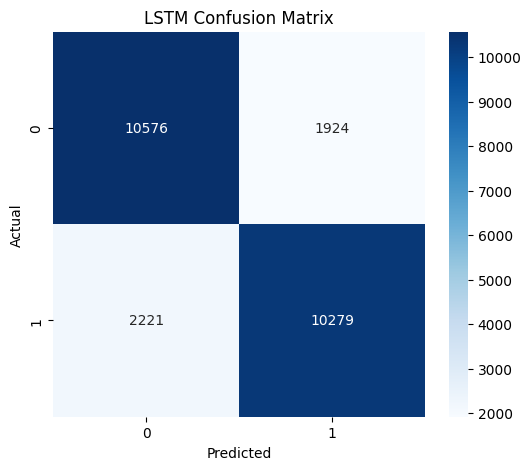

In [51]:
# Cell 46

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("LSTM Confusion Matrix")

plt.savefig("confusion_matrix_lstm.png")

plt.show()

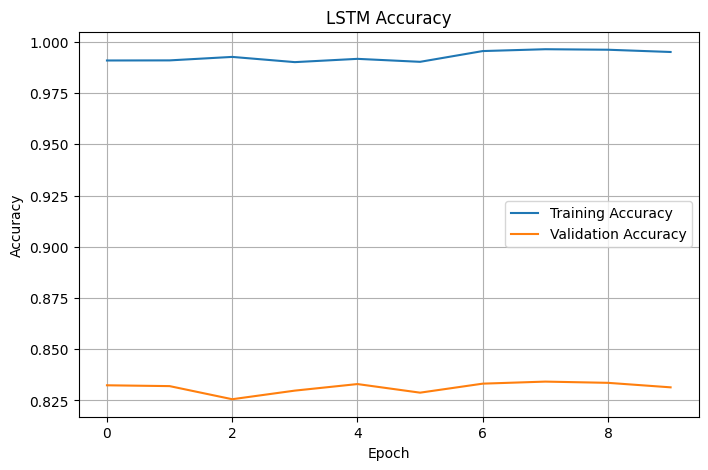

In [62]:
# Cell 47

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')

plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title("LSTM Accuracy")

plt.legend()

plt.grid(True)

plt.savefig("accuracy.png")

plt.show()

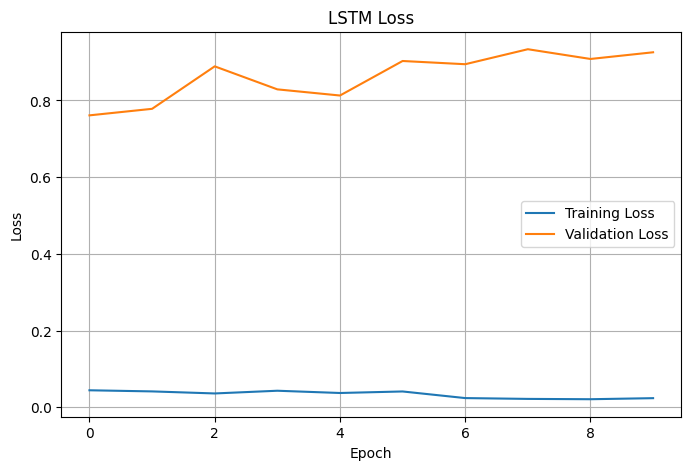

In [63]:
# Cell 48

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')

plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("LSTM Loss")

plt.legend()
plt.grid(True)

plt.savefig("loss.png", dpi=300)

plt.show()

In [64]:
# Cell 49

comparison = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "SVM",
        "LSTM"
    ],

    "Accuracy": [
        lr_accuracy,
        svm_accuracy,
        accuracy
    ],

    "Precision": [
        lr_precision,
        svm_precision,
        precision
    ],

    "Recall": [
        lr_recall,
        svm_recall,
        recall
    ],

    "F1 Score": [
        lr_f1,
        svm_f1,
        f1
    ]

})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.87288,0.869627,0.87728,0.873437
1,SVM,0.85680,0.858752,0.85408,0.856409
2,LSTM,0.82928,0.842334,0.82232,0.832207


In [65]:
# Cell 50

comparison.to_csv("comparison_results.csv", index=False)

print("Comparison Results Saved Successfully!")

Comparison Results Saved Successfully!


In [66]:
# Cell 51

model.save("lstm_sentiment_model.keras")

print("LSTM Model Saved Successfully!")

LSTM Model Saved Successfully!


In [67]:
# Cell 52

import pickle

with open("history.pkl", "wb") as file:

    pickle.dump(history.history, file)

print("History Saved Successfully!")

History Saved Successfully!


In [68]:
# Cell 53

print("="*60)
print("TASK 2 COMPLETED SUCCESSFULLY")
print("="*60)

print("Logistic Regression Accuracy :", round(lr_accuracy,4))
print("SVM Accuracy :", round(svm_accuracy,4))
print("LSTM Accuracy :", round(accuracy,4))

print("="*60)
print("GitHub Files Ready to Upload")
print("="*60)

TASK 2 COMPLETED SUCCESSFULLY
Logistic Regression Accuracy : 0.8729
SVM Accuracy : 0.8568
LSTM Accuracy : 0.8293
GitHub Files Ready to Upload
